In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

# Basic exploration
print("First 5 rows:")
print(df.head())

print("\nFeature names:")
print(wine.feature_names)

print("\nClass distribution:")
print(df['target'].value_counts())

# Standardize the data (z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

In [2]:
from sklearn.cluster import KMeans

# K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Results:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_ari:.4f}")

K-Means Results:
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975


In [5]:
!pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids

# K-Medoids with k=3
kmedoids = KMedoids(n_clusters=3, random_state=42, method='pam')
kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Evaluation metrics
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("\nK-Medoids Results:")
print(f"Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmedoids_ari:.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 7.9 MB/s  0:00:00
  Installing build dependencdone
  Getting requirements to build wheel ... one
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp310-cp310-macosx_11_0_arm64.whl size=403202 sha256=a3042520977dd9143be7907b334cc0525231b961766bc3cd559d4f70ee40afcb
  Stored in directory: /Users/tanmay/Library/Caches/pip/wheels/60/e1/7f/881b5af199acf453d55d49d38e227d291fe5b562099ac29a68
Successfully built scikit-learn-extra

K-Medoids Results:
Silhouette Score: 0.2676
Adjusted Rand Index (ARI): 0.7411


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

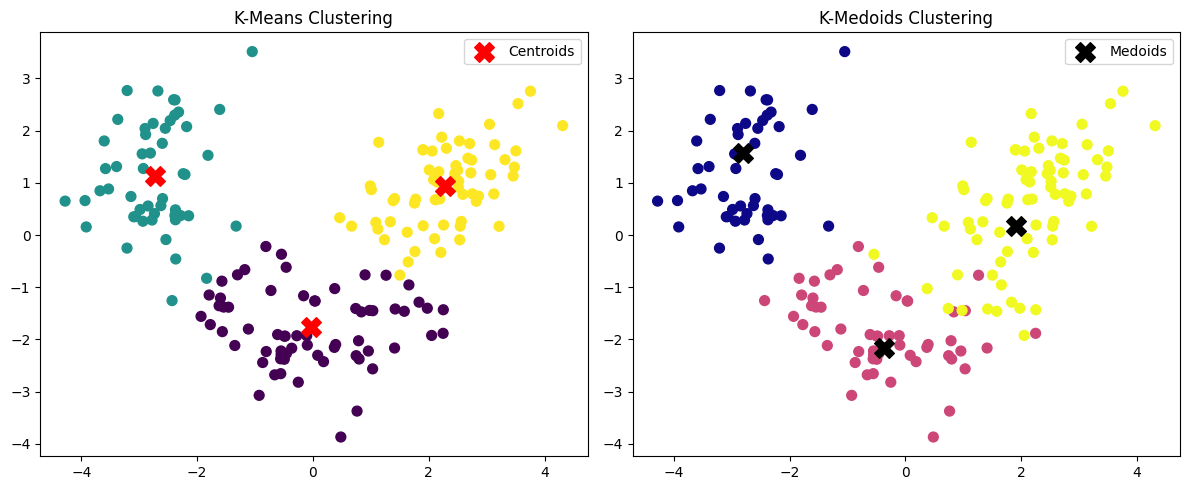

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- K-Means Plot ---
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50)
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[0].set_title("K-Means Clustering")
axes[0].legend()

# --- K-Medoids Plot ---
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, cmap='plasma', s=50)
medoids_pca = pca.transform(kmedoids.cluster_centers_)
axes[1].scatter(medoids_pca[:, 0], medoids_pca[:, 1],
                c='black', marker='X', s=200, label='Medoids')
axes[1].set_title("K-Medoids Clustering")
axes[1].legend()

plt.tight_layout()
plt.show()